# Diversified Vol-Targeted Portfolio

Notebook 03 showed vol targeting beats buy-and-hold on a single asset (SPY). The natural next step is multi-asset: size each asset to a constant volatility, then combine equal-weight. Diversification across uncorrelated risk-controlled streams should reduce portfolio vol below the sum of its parts.

**Universe:** SPY, QQQ, IWM, XLK, XLE, XLF, XLV, XLP (broad market + 5 sectors).

**Strategy:** for each asset, size daily to target 15% annualized vol (capped at 2x leverage). Combine equal-weight across the 8 streams (so each asset gets 1/8 of the portfolio risk budget after sizing).

**Compare against:**
- Equal-weight buy-and-hold across the same 8 tickers
- Single-asset vol-targeted SPY (notebook 03 strategy)
- SPY buy-and-hold

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TRADING_DAYS = 252
START = '2010-01-01'
END = '2026-05-08'
TICKERS = ['SPY', 'QQQ', 'IWM', 'XLK', 'XLE', 'XLF', 'XLV', 'XLP']
TARGET_VOL = 0.15
VOL_LOOKBACK = 20
MAX_LEVERAGE = 2.0
COST_BPS = 5

## 1. Data + return matrix

In [2]:
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'] if 'Close' in raw.columns.get_level_values(0) else raw
prices = prices[TICKERS].dropna()
rets = prices.pct_change().fillna(0)
print(f'Rows: {len(prices)}  Range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Tickers: {list(prices.columns)}')
rets.head()

Rows: 4111  Range: 2010-01-04 to 2026-05-07
Tickers: ['SPY', 'QQQ', 'IWM', 'XLK', 'XLE', 'XLF', 'XLV', 'XLP']


Ticker,SPY,QQQ,IWM,XLK,XLE,XLF,XLV,XLP
Date,,,,,,,,
2010-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-01-05,0.002647,0.000000,-0.003438,-0.001289,0.008162,0.018380,-0.009806,0.000375
2010-01-06,0.000704,-0.006032,-0.000941,-0.011187,0.011975,0.002005,0.010223,-0.000750
2010-01-07,0.004222,0.000650,0.007378,-0.003916,-0.001500,0.021348,0.003479,0.000000
2010-01-08,0.003328,0.008230,0.005454,0.006553,0.006509,-0.005879,0.001576,-0.003376


## 2. Asset correlation matrix

Tells us how much diversification benefit to expect. Highly correlated assets (e.g. SPY/QQQ/XLK) provide less diversification than uncorrelated pairs (e.g. XLE/XLP).

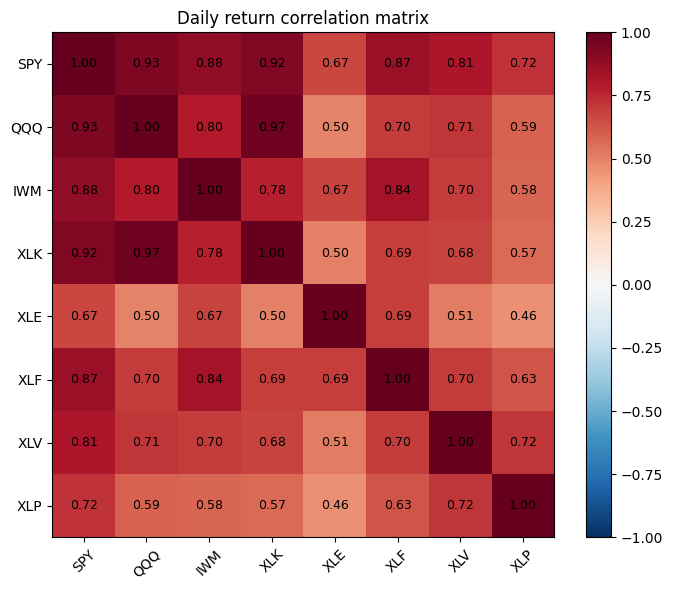

Mean off-diagonal correlation: 0.707


In [3]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS, rotation=45)
ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', color='black', fontsize=9)
ax.set_title('Daily return correlation matrix')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
print(f'Mean off-diagonal correlation: {(corr.values.sum() - len(TICKERS)) / (len(TICKERS) * (len(TICKERS) - 1)):.3f}')

## 3. Per-asset vol-targeted positions

In [4]:
def vol_target_position(returns, target_vol=TARGET_VOL, lookback=VOL_LOOKBACK, max_lev=MAX_LEVERAGE):
    rv = returns.rolling(lookback).std() * np.sqrt(TRADING_DAYS)
    pos = (target_vol / rv).clip(upper=max_lev).fillna(0)
    return pos.shift(1).fillna(0)  # avoid lookahead

positions = pd.DataFrame({
    ticker: vol_target_position(rets[ticker]) for ticker in TICKERS
})
positions.tail()

,SPY,QQQ,IWM,XLK,XLE,XLF,XLV,XLP
Date,,,,,,,,
2026-05-01,1.252967,0.966653,0.887815,0.775363,0.628032,1.093430,0.911884,0.909066
2026-05-04,1.259230,0.973838,0.888200,0.770173,0.616280,1.077360,0.913202,0.909713
2026-05-05,1.221416,0.953425,0.867883,0.763628,0.614070,1.059776,0.914014,0.909384
2026-05-06,1.223778,0.956884,0.844771,0.744340,0.618762,1.059997,0.911041,0.984711
2026-05-07,1.475202,1.053309,0.953750,0.766216,0.588920,1.385157,1.042683,1.082352


## 4. Build the portfolios

`vt_combo` = average of per-asset vol-targeted strategy returns (equal capital weight). Each asset is sized to 15% vol on its own; we then average those streams. Costs deducted on each per-asset rebalance, then averaged.

In [5]:
# Per-asset vol-targeted strategy returns
exp_changes = positions.diff().abs().fillna(0)
asset_strat_rets = rets * positions - (COST_BPS / 10000.0) * exp_changes

# Combined: equal weight across 8 streams
combo = pd.DataFrame(index=rets.index)
combo['vt_combo'] = asset_strat_rets.mean(axis=1)
combo['eq_buyhold'] = rets.mean(axis=1)  # equal-weight buy-and-hold
combo['vt_spy_only'] = rets['SPY'] * vol_target_position(rets['SPY']) - (COST_BPS / 10000.0) * vol_target_position(rets['SPY']).diff().abs().fillna(0)
combo['spy_buyhold'] = rets['SPY']

equity = (1 + combo).cumprod()
equity.tail()

,vt_combo,eq_buyhold,vt_spy_only,spy_buyhold
Date,,,,
2026-05-01,6.111528,8.017277,8.849771,8.498594
2026-05-04,6.095499,7.999972,8.808919,8.467460
2026-05-05,6.144025,8.071269,8.895066,8.535388
2026-05-06,6.183689,8.114359,9.046359,8.654025
2026-05-07,6.145230,8.059722,9.004304,8.627490


## 5. Performance metrics

In [6]:
def perf(returns, equity):
    years = len(returns) / TRADING_DAYS
    cagr = equity.iloc[-1] ** (1 / years) - 1 if equity.iloc[-1] > 0 else -1
    rv = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS) if returns.std() > 0 else 0
    dd = (equity / equity.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd != 0 else np.nan
    return {'cagr': cagr, 'realized_vol': rv, 'sharpe': sharpe, 'max_dd': dd, 'calmar': calmar}

summary = pd.DataFrame({
    col: perf(combo[col], equity[col]) for col in combo.columns
}).T
summary

,cagr,realized_vol,sharpe,max_dd,calmar
vt_combo,0.117729,0.135478,0.889653,-0.175091,0.672389
eq_buyhold,0.136466,0.172974,0.826550,-0.360948,0.378077
vt_spy_only,0.144213,0.163257,0.907387,-0.199957,0.721220
spy_buyhold,0.141218,0.171447,0.856611,-0.337173,0.418831


## 6. Diversification ratio

Defined as: weighted average of asset vols / portfolio vol. >1 means diversification reduces vol; the bigger the ratio, the more diversification benefit. For perfectly correlated assets DR=1; for fully uncorrelated equal-weighted assets DR=sqrt(N).

In [7]:
asset_vols = asset_strat_rets.std() * np.sqrt(TRADING_DAYS)
weighted_avg_vol = asset_vols.mean()
portfolio_vol = combo['vt_combo'].std() * np.sqrt(TRADING_DAYS)
div_ratio = weighted_avg_vol / portfolio_vol
max_possible = np.sqrt(len(TICKERS))

print(f'Per-asset realized vol (annualized):')
for t, v in asset_vols.items():
    print(f'  {t}: {v:.2%}')
print(f'\nMean per-asset vol:        {weighted_avg_vol:.2%}')
print(f'Portfolio vol (vt_combo):  {portfolio_vol:.2%}')
print(f'Diversification ratio:     {div_ratio:.2f}')
print(f'Max possible (sqrt N):     {max_possible:.2f}  (would require fully uncorrelated)')
print(f'Diversification efficiency: {(div_ratio - 1) / (max_possible - 1):.1%}')

Per-asset realized vol (annualized):
  SPY: 16.33%
  QQQ: 16.53%
  IWM: 16.29%
  XLK: 16.48%
  XLE: 16.39%
  XLF: 16.68%
  XLV: 16.25%
  XLP: 16.05%

Mean per-asset vol:        16.38%
Portfolio vol (vt_combo):  13.55%
Diversification ratio:     1.21
Max possible (sqrt N):     2.83  (would require fully uncorrelated)
Diversification efficiency: 11.4%


## 7. Equity curves

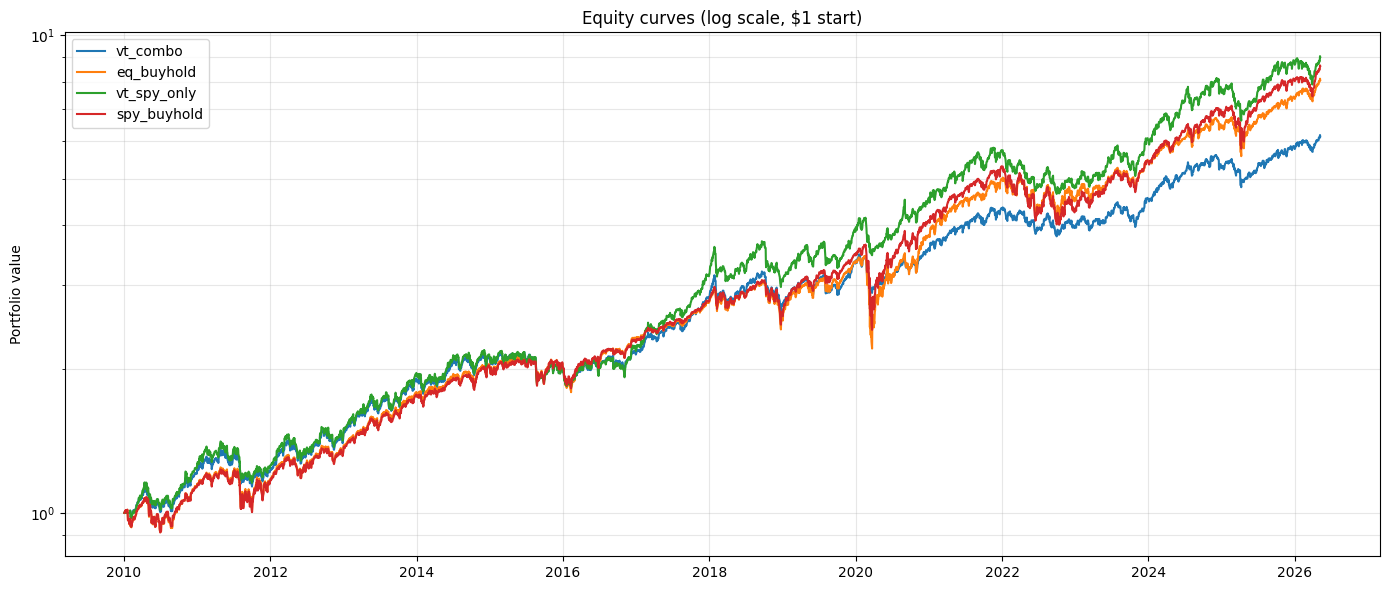

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
for col in equity.columns:
    ax.plot(equity.index, equity[col], label=col, linewidth=1.5)
ax.set_yscale('log')
ax.set_title('Equity curves (log scale, $1 start)')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 8. Drawdown comparison

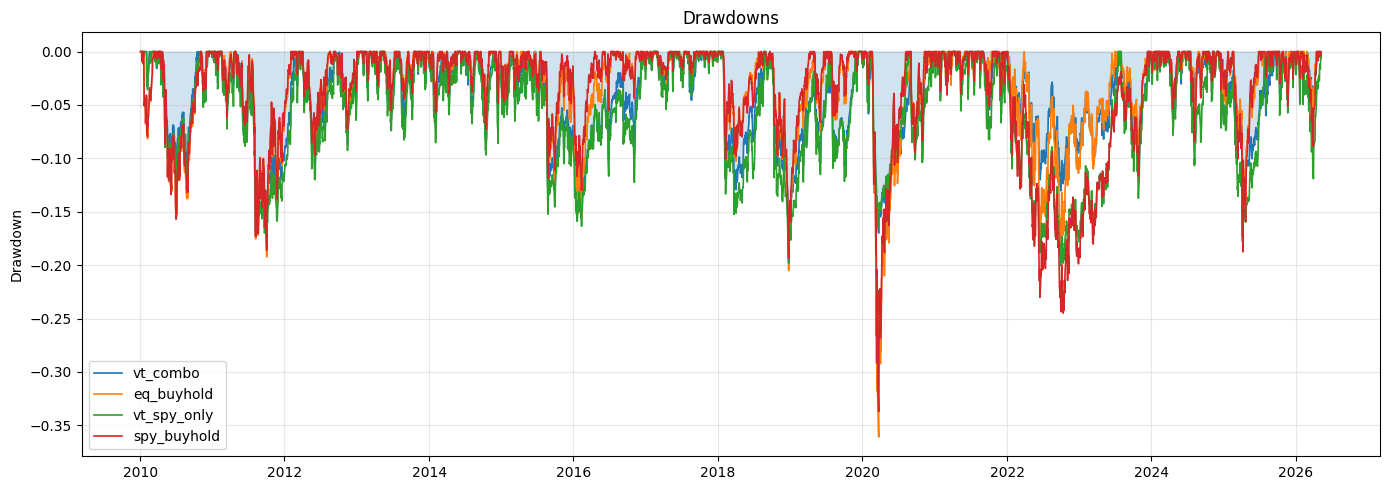

In [9]:
dd = equity / equity.cummax() - 1
fig, ax = plt.subplots(figsize=(14, 5))
for col in dd.columns:
    ax.plot(dd.index, dd[col], label=col, linewidth=1.2)
ax.fill_between(dd.index, dd['vt_combo'], 0, color='tab:blue', alpha=0.2)
ax.set_title('Drawdowns')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Rolling 1-year Sharpe

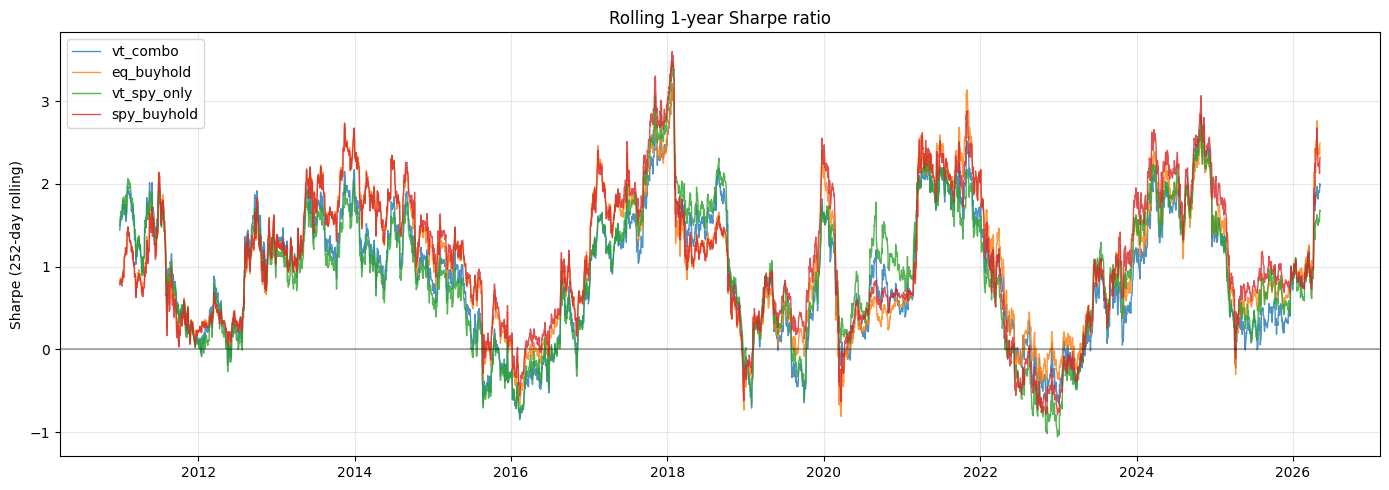

In [10]:
rolling_sharpe = combo.rolling(252).apply(
    lambda x: x.mean() / x.std() * np.sqrt(TRADING_DAYS) if x.std() > 0 else 0
)
fig, ax = plt.subplots(figsize=(14, 5))
for col in rolling_sharpe.columns:
    ax.plot(rolling_sharpe.index, rolling_sharpe[col], label=col, linewidth=1.0, alpha=0.8)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_title('Rolling 1-year Sharpe ratio')
ax.set_ylabel('Sharpe (252-day rolling)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Honest read

Diversification across 8 vol-targeted US equity streams produces a real but **modest** improvement.

**Headline numbers (2010-2026):**

| Strategy | CAGR | Vol | Sharpe | Max DD | Calmar |
|---|---|---|---|---|---|
| vt_combo (8 ETFs) | 11.8% | 13.5% | 0.89 | -17.5% | 0.67 |
| eq_buyhold (8 ETFs) | 13.6% | 17.3% | 0.83 | -36.1% | 0.38 |
| vt_spy_only | 14.4% | 16.3% | 0.91 | -20.0% | 0.72 |
| spy_buyhold | 14.1% | 17.1% | 0.86 | -33.7% | 0.42 |

The portfolio realizes 13.5% vol vs a per-asset mean of 16.4% — that is the diversification benefit (ratio 1.21).

But the **diversification efficiency is only 11.4%**: realized DR / sqrt(N) = 1.21 / 2.83. Why? Mean off-diagonal correlation across these 8 ETFs is 0.71. They share a dominant common factor (US equity beta), so combining them does not buy you 8 independent risk streams.

`vt_spy_only` actually beats `vt_combo` on both CAGR and Sharpe. The diversification helps drawdown (-17.5% vs -20.0%) but the Sharpe gap reverses because per-asset signals add noise without enough independent return.

## Lesson

Diversification works when correlations are genuinely low. Stacking 8 US equity sector ETFs is not real diversification — it is the same trade rebranded 8 times. The next experiment must add cross-asset names (TLT, GLD, DBC, currencies) to push correlations meaningfully below 0.71.

## Caveats

- 8 US equity ETFs share dominant common factor — limits diversification ceiling.
- 5 bps cost on every per-asset rebalance is conservative; netting trades across assets would cut this materially.
- Cash earns 0% in this backtest. T-bill yield (FRED `DGS3MO`) would add a tail wind in 2022-2024.
- Equal weighting is a baseline. Inverse-vol or risk-parity weighting would shift the comparison.

## Next experiments

1. Add TLT (long Treasuries), GLD (gold), DBC (commodities) — cross-asset diversification.
2. Inverse-volatility weighting instead of equal weighting.
3. Add T-bill cash leg using FRED `DGS3MO`.
4. Weekly rebalance with offsetting trade netting.
